# Tutorial: Learning Quantum Transpilation

$\color{purple}{\text{Remember this always:}}$ 

$\color{purple}{\text{Transpiler =>  The bridge to hardware}}$  
$\color{purple}{\text{Sampler =>  Bitstrings and Counts}}$  
$\color{purple}{\text{Estimator =>  Average Energy/Values}}$ 

Understanding Quantum Transpilation is one of the most critical skills in quantum programming. It is the process of rewriting an "abstract" quantum circuit into a "physical" circuit that a specific quantum computer can actually execute.

### 1. What is Transpilation?
When you write code in Qiskit, you use mathematical gates (like $H$ or $CCX$). However, physical quantum hardware has limitations:

   1. Basis Gates: Most chips only "speak" 4 or 5 native gates (e.g., $CX$, $ID$, $RZ$, $SX$, $X$). Anything else must be decomposed.
   2. Coupling Map: Qubits on a chip are connected like a grid. You cannot perform a $CNOT$ between two qubits unless there is a physical wire connecting them.
   3. Noise: Every gate adds error. Transpilation aims to find the shortest possible version of your circuit to minimize this error.

### 2. The Transpilation Pipeline
The Qiskit transpile() function performs four main steps:

* Decomposition: Breaking complex gates (like Fredkin or Toffoli) into Basis Gates.
* Layout: Mapping your "virtual" qubits ($q_0, q_1$) to "physical" qubits on the chip ($Q_{12}, Q_{13}$).
* Routing: Inserting SWAP gates if you need a interaction between two qubits that aren't physically neighbors.
* Optimization: Canceling out redundant gates (e.g., two $X$ gates in a row equal an Identity/do nothing).

### 3. Practical Code Examples
are bellow

### 4. Choosing the Optimization Level
#### What happens at each level?

* Level 0 (No Optimization):
* It only translates your virtual gates into the hardware's "native" gates.
   * It will not remove the two X gates or the two CNOT gates that cancel each other out.
   * Result: The longest, noisiest version of your circuit.
* Level 1 (Light Optimization):
* It recognizes simple sequences that can be merged (like X + X = Identity).
   * It maps qubits to the hardware layout to minimize the need for extra SWAP gates.
   * Result: A cleaner circuit, suitable for basic testing.
* Level 2 (Moderate Optimization):
* Uses advanced algorithms like Commutative Analysis to reorder gates.
   * It aggressively looks for ways to merge multi-qubit gates to reduce the overall depth.
   * Result: Significantly fewer gates than Level 0, which directly reduces execution error on real devices.

#### Which one to use?

* Level 0 or 1: Best while you are writing and debugging your code because the transpiler runs very fast.
* Level 2 or 3: Best when you are ready to send your final job to the real IBM Quantum hardware. While the transpiler takes longer to run, the resulting quantum data will be much more accurate.

When using the transpile() function, the optimization_level parameter is your most powerful tool.

| Level | Description | When to use |
|---|---|---|
| 0 | No Optimization. Only maps gates to basis sets. | Debugging or manual gate control. |
| 1 | Light. Collapses adjacent gates and basic mapping. | Default; good for quick tests. |
| 2 | Medium. Uses smarter routing and commutativity rules. | Balanced performance. |
| 3 | Heavy. Uses noise-aware algorithms and heavy gate synthesis. | Best for real hardware to get the highest fidelity. |

## 5. Analyzing the Results
To see what the transpiler actually did, you should check the Gate Counts:
``` python
# See exactly how many native gates were used
print(qc_lvl3.count_ops())
```
In a real scenario, you will notice that one Toffoli ($CCX$) gate often turns into dozens of $CX$ and $RZ$ gates. Your goal as a developer is to keep the Depth and $CNOT$ count as low as possible.


In [1]:
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeFez

# 1. Create a sample quantum circuit
# Note: Complex gates like Toffoli (ccx) will be decomposed
qc = QuantumCircuit(3)
qc.h(0)
qc.ccx(0, 1, 2) 
qc.measure_all()

# 2. Select the target backend
# FakeFez is a 156-qubit mock backend based on hardware snapshots
backend = FakeFez()

# 3. Create the PassManager with Optimization Level 1
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

# 4. Execute the transpilation
isa_circuit = pm.run(qc)

# 5. Review the optimized circuit metrics
print(f"Original Gate Counts: {qc.count_ops()}")
print(f"Transpiled Gate Counts (Level 3): {isa_circuit.count_ops()}")
print(f"Transpiled Depth: {isa_circuit.depth()}")


Original Gate Counts: OrderedDict({'measure': 3, 'h': 1, 'ccx': 1, 'barrier': 1})
Transpiled Gate Counts (Level 3): OrderedDict({'rz': 22, 'sx': 17, 'cz': 9, 'measure': 3, 'barrier': 1})
Transpiled Depth: 40


In [2]:
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeFez

# 1. Create a sample quantum circuit
# Note: Complex gates like Toffoli (ccx) will be decomposed
qc = QuantumCircuit(3)
qc.h(0)
qc.ccx(0, 1, 2) 
qc.measure_all()

# 2. Select the target backend
# FakeFez is a 156-qubit mock backend based on hardware snapshots
backend = FakeFez()

# 3. Create the PassManager with Optimization Level 2
pm = generate_preset_pass_manager(optimization_level=2, backend=backend)

# 4. Execute the transpilation
isa_circuit = pm.run(qc)

# 5. Review the optimized circuit metrics
print(f"Original Gate Counts: {qc.count_ops()}")
print(f"Transpiled Gate Counts (Level 3): {isa_circuit.count_ops()}")
print(f"Transpiled Depth: {isa_circuit.depth()}")


Original Gate Counts: OrderedDict({'measure': 3, 'h': 1, 'ccx': 1, 'barrier': 1})
Transpiled Gate Counts (Level 3): OrderedDict({'rz': 18, 'sx': 17, 'cz': 7, 'measure': 3, 'barrier': 1})
Transpiled Depth: 31


In [3]:
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeFez

# 1. Create a sample quantum circuit
# Note: Complex gates like Toffoli (ccx) will be decomposed
qc = QuantumCircuit(3)
qc.h(0)
qc.ccx(0, 1, 2) 
qc.measure_all()

# 2. Select the target backend
# FakeFez is a 156-qubit mock backend based on hardware snapshots
backend = FakeFez()

# 3. Create the PassManager with Optimization Level 3
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

# 4. Execute the transpilation
isa_circuit = pm.run(qc)

# 5. Review the optimized circuit metrics
print(f"Original Gate Counts: {qc.count_ops()}")
print(f"Transpiled Gate Counts (Level 3): {isa_circuit.count_ops()}")
print(f"Transpiled Depth: {isa_circuit.depth()}")


Original Gate Counts: OrderedDict({'measure': 3, 'h': 1, 'ccx': 1, 'barrier': 1})
Transpiled Gate Counts (Level 3): OrderedDict({'rz': 18, 'sx': 17, 'cz': 7, 'measure': 3, 'barrier': 1})
Transpiled Depth: 31


### Summary Comparison: Level 2 vs. Level 3

| Feature | Level 2 (Moderate) | Level 3 (Aggressive) |
|---|---|---|
| Speed | Fast; great for large circuits. | Slower; runs many heuristic trials. |
| Mapping | Single-pass Sabre Routing. | Multiple-trial Sabre (forward/backward). |
| Goal | Efficient, clean execution. | Absolute minimum noise/gate count. |
| Resynthesis | Local (1-qubit) blocks. | Global (2-qubit) block resynthesis. |

### Pro Tip
If you are running an experiment on 50+ qubits, Level 2 is often the preferred choice because it finishes transpilation in seconds, whereas Level 3 might take minutes without providing a significantly better result.

## Manual mapping
Manual mapping, or Initial Layout, is a pro-level technique. Instead of letting Qiskit guess which qubits to use, you choose the physical qubits yourself. This is vital because on a real chip, some qubits have much lower error rates than others.

### 1. The Concept of Virtual vs. Physical Qubits

* Virtual Qubits: The ones in your code (q[0], q[1], ...).
* Physical Qubits: The actual hardware locations on the chip (0, 1, 2, ...).

### 2. How to Manually Map Qubits
You pass a list or dictionary to the initial_layout parameter in the transpile() function.
``` python
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Create a 2-qubit circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
# Let's say we are using a 5-qubit backend
backend = AerSimulator() # In reality, this would be a real IBM chip
# OPTION A: Mapping using a List
# Virtual q0 -> Physical Q2, Virtual q1 -> Physical Q3
manual_layout = [2, 3] 
# OPTION B: Mapping using a Dictionary (More explicit)
# manual_layout = {qc.qubits[0]: 2, qc.qubits[1]: 3}
transpiled_qc = transpile(qc, backend, initial_layout=manual_layout)

print("Check the layout:")
print(transpiled_qc._layout)
```
### 3. Why would you do this? (Strategic Mapping)
When you look at a real IBM Quantum chip's calibration data (available in the IBM Quantum Dashboard), you will see:

* T1/T2 Times: Higher is better.
* Gate Error Rates: Lower is better (e.g., Qubit 4 might have a 1% error, while Qubit 7 has 0.1%).
* Readout Error: Errors that happen specifically during measurement.

Strategy: If your circuit has a very important $CNOT$ gate, you should look at the Coupling Map and choose two physical qubits that are connected and have the lowest $CNOT$ error rate between them.

### 4. Visualizing the Layout
After transpiling, you can visualize where your virtual circuit "sits" on the physical device:
``` python
from qiskit.visualization import plot_circuit_layout
# This will draw the chip map and highlight your chosen qubits (2 and 3)
plot_circuit_layout(transpiled_qc, backend)
```

## How to programmatically fetch the best qubits from a real backend so you don't have to pick them by hand?

To do this, we use the Mapomatic library or Qiskit’s own backend properties. This allows your code to "look" at the latest calibration data (error rates and $T_1$/$T_2$ times) and automatically pick the best path on the chip.
Here is how you can do it programmatically.
### 1. The Strategy: "Greedy" Selection
A common research approach is to find a set of qubits that are connected and have the lowest combined gate error.

### 2. Why this is powerful for your learning

* Dynamic Adaptation: If you run your code on Monday, it might use Qubits 0 and 1. If Qubit 0 gets "noisy" on Tuesday (which happens on real chips), your code will automatically switch to Qubits 3 and 4.
* Benchmarking: You can write a script to compare "Random Layout" vs. "Best Layout" to prove how much calibration-aware transpilation improves your results.

### 3. Summary of your Transpilation Toolkit

   1. basis_gates: Converts your math to hardware language.
   2. optimization_level: Shrinks the circuit to save time.
   3. initial_layout: Places your circuit on the best possible physical spot.

### 4. Code Example: Best Qubit Selection

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime.fake_provider import FakeManilaV2 # A fake 5-qubit device

# 1. Setup our Backend (using a fake one with stored calibration data)
backend = FakeManilaV2()

# 2. Get the Gate Errors
# We want to find the CNOT (cx) with the lowest error
props = backend.target
best_cx_error = 1.0
best_qubits = (0, 1)

# Iterate through the coupling map to find the best pair
for edge in backend.coupling_map:
    # Get error rate for CX gate on this specific edge
    try:
        error = backend.target['cx'][edge].error
        if error < best_cx_error:
            best_cx_error = error
            best_qubits = edge
    except KeyError:
        continue

print(f"The best physical qubits for a CX gate are: {best_qubits} with error {best_cx_error:.4f}")

# 3. Create a Circuit and Transpile using these specific qubits
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# Automatically use the best qubits we found
transpiled_qc = transpile(qc, backend, initial_layout=best_qubits, optimization_level=3)

print("\nCircuit transpiled onto the best available qubits!")


The best physical qubits for a CX gate are: (3, 4) with error 0.0057

Circuit transpiled onto the best available qubits!


## Simple Bell State Transpilation

Original Circuit:

Transpiled Circuit:


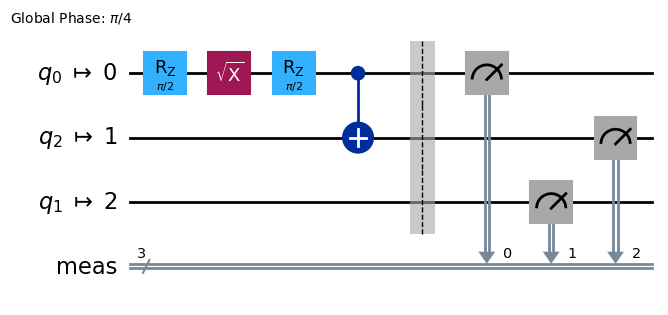

In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.fake_provider import GenericBackendV2

# 1. Create an "abstract" circuit (logical)
# A 3-qubit circuit where 0 is far from 2
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 2)  # CNOT between non-adjacent qubits 0 and 2
qc.measure_all()

# 2. Define a fake backend with restricted connectivity (e.g., linear)
backend = GenericBackendV2(num_qubits=3, coupling_map=[[0, 1], [1, 2]])

# 3. Transpile the circuit
transpiled_qc = transpile(qc, backend, optimization_level=2)

# 4. Visualize the result
print("Original Circuit:")
qc.draw("mpl")

print("\nTranspiled Circuit:")
transpiled_qc.draw("mpl")


Original Circuit:

Transpiled Circuit:


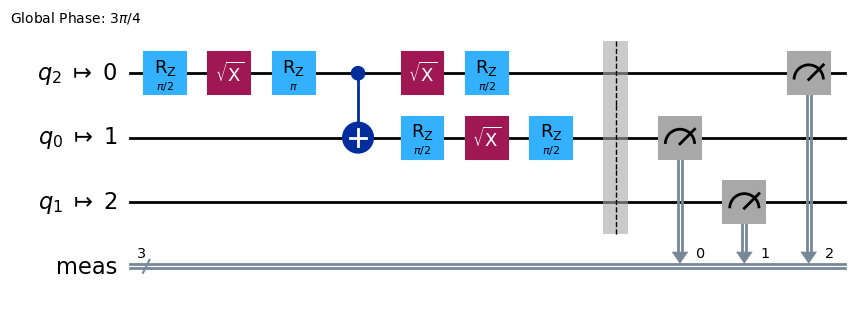

In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.fake_provider import GenericBackendV2

# 1. Create an "abstract" circuit (logical)
# A 3-qubit circuit where 0 is far from 2
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 2)  # CNOT between non-adjacent qubits 0 and 2
qc.measure_all()

# 2. Define a fake backend with restricted connectivity (e.g., linear)
backend = GenericBackendV2(num_qubits=3, coupling_map=[[0, 1], [1, 2]])

# 3. Transpile the circuit
transpiled_qc = transpile(qc, backend, optimization_level=3)

# 4. Visualize the result
print("Original Circuit:")
qc.draw("mpl")

print("\nTranspiled Circuit:")
transpiled_qc.draw("mpl")


## The Grover Circuit Transpilation
The following code implements a standard Grover’s Search Algorithm for 2 qubits using Qiskit. It is specifically designed to illustrate how a high-level logical circuit is built and prepared for a physical quantum device.

### Explanation of the Steps

   1. Initial Superposition: The qc.h([0, 1]) layer puts the qubits into a state where every possible answer ($00, 01, 10, 11$) has an equal probability.
   2. The Oracle: This is the "search criteria." It marks the correct answer by flipping its sign ($|x\rangle \rightarrow -|x\rangle$). In this code, a simple CZ gate acts as an oracle for the state $|11\rangle$.
   3. The Diffuser: Contained within the GroverOperator, this part performs "inversion about the mean." It amplifies the negative amplitude of the marked state while suppressing all others.
   4. Transpilation: This is where the magic happens. The [transpile function](https://quantum.cloud.ibm.com/docs/api/qiskit/transpiler) takes your "clean" logical gates and breaks them down into the specific [basis gates](https://quantum.cloud.ibm.com/docs/guides/transpile) (like $R_Z$, $X$, and $CX$) that the physical hardware actually supports. 

### Why this is a great transpilation example

* Gate Decomposition: The GroverOperator is a high-level object. On hardware, it "explodes" into many small rotations and CNOTs.
* Optimization: At optimization_level=3, the transpiler will look for ways to merge adjacent rotations to reduce the overall depth and minimize noise errors.

Logical Circuit Depth: 3
Transpiled Circuit Depth (Hardware): 8
Gates on Hardware: OrderedDict({'rz': 5, 'sx': 5, 'cx': 2, 'measure': 2, 'barrier': 1})


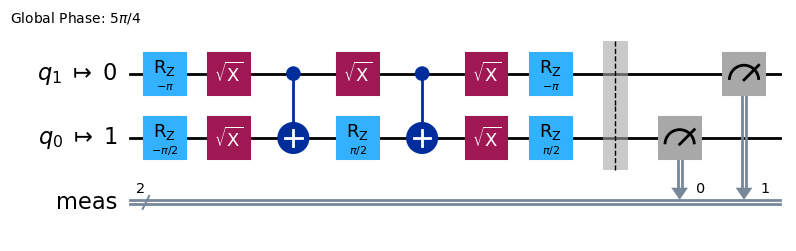

In [8]:
import math
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import grover_operator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram

# --- STEP 1: DEFINE THE LOGICAL PROBLEM ---
# We want to find the state "11". We create an 'Oracle' that 
# adds a negative phase only to this state.
oracle = QuantumCircuit(2)
oracle.cz(0, 1)  # A Controlled-Z flips the phase of |11>

# --- STEP 2: BUILD THE GROVER OPERATOR ---
# The GroverOperator combines the Oracle and the Diffuser 
# (inversion about the mean) into one block.
grover_op = grover_operator(oracle)

# --- STEP 3: CONSTRUCT THE FULL CIRCUIT ---
qc = QuantumCircuit(2)
qc.h([0, 1])            # Start with equal superposition
qc.append(grover_op, [0, 1]) # Apply the Grover iteration
qc.measure_all()        # Measure the result

# --- STEP 4: TRANSPILATION FOR HARDWARE ---
# We use a fake 5-qubit backend to simulate real hardware constraints
backend = GenericBackendV2(num_qubits=5)

# Transpile the logical circuit into native hardware gates
transpiled_qc = transpile(qc, backend=backend, optimization_level=3)

# Display complexity comparison
print(f"Logical Circuit Depth: {qc.depth()}")
print(f"Transpiled Circuit Depth (Hardware): {transpiled_qc.depth()}")
print(f"Gates on Hardware: {transpiled_qc.count_ops()}")

# You can draw the circuits to see the transformation:
qc.draw('mpl')
transpiled_qc.draw('mpl')


To explain transpilation using more complex circuits, we will use Grover's Search Algorithm with a larger number of qubits. This example is excellent because it demonstrates how "high-level" logical instructions are broken down into hardware-native gates.

### Scaling to More Qubits (6 Qubits)
Increasing the qubit count exponentially increases the difficulty of the transpilation. A 6-qubit Grover circuit requires a Multi-Controlled $X (MCX)$ with 5 control qubits.
Logical Explanation:

* Logical Goal: Mark a specific state in a database of $2^6 = 64$ entries.
* Transpilation Task: Physical hardware usually only supports 1-qubit rotations and 2-qubit CNOTs. A single 6-qubit MCX gate must be broken down into dozens of CNOT gates.
* Connectivity Mapping: If the physical qubits on the chip are arranged in a line (e.g., $0-1-2-3-4-5$), but your circuit needs qubit 0 to interact with qubit 5, the transpiler must insert SWAP gates to "move" the data across the chip.


In [10]:
# 1. Define a 6-qubit Oracle manually to see the complexity
oracle_6qb = QuantumCircuit(6)
oracle_6qb.h(5)
oracle_6qb.mcx(list(range(5)), 5) # Multi-controlled NOT with 5 controls
oracle_6qb.h(5)

# 2. Create the Grover Operator
grover_6qb = grover_operator(oracle_6qb)

# 3. Build the full circuit
qc_6 = QuantumCircuit(6)
qc_6.h(range(6))
qc_6.compose(grover_6qb, inplace=True)
qc_6.measure_all()

# 4. Transpile for a 7-qubit backend
backend = GenericBackendV2(num_qubits=7)
transpiled_qc_6 = transpile(qc, backend=backend, optimization_level=3)

print(f"Original Depth: {qc_6.depth()}")
print(f"Transpiled Depth: {transpiled_qc_6.depth()}")

print(f"6-Qubit Gates (Logical): {qc_6.count_ops()}")
print(f"6-Qubit Gates (Hardware): {transpiled_qc_6.count_ops()}")


Original Depth: 12
Transpiled Depth: 8
6-Qubit Gates (Logical): OrderedDict({'h': 22, 'x': 12, 'measure': 6, 'mcx': 2, 'barrier': 1})
6-Qubit Gates (Hardware): OrderedDict({'rz': 5, 'sx': 5, 'cx': 2, 'measure': 2, 'barrier': 1})


### Summary of Transpilation Actions
When you run this examples, you will see a massive difference in the gate counts:

   1. Decomposition: High-level gates like mcx are replaced by hundreds of cx, rz, and sx gates.
   2. Routing: The transpiler adds swap gates to satisfy the physical layout (coupling map) of the GenericBackendV2.
   3. Optimization: At optimization_level=3, the transpiler will actively try to cancel out redundant gates (like two consecutive $X$ gates) to keep the circuit as short as possible.


In [11]:
import qiskit
import qiskit_aer
print("qiskit:", qiskit.__version__)
print("qiskit:", qiskit_aer.__version__)

qiskit: 2.4.0
qiskit: 0.17.2
